# Comparing mfrac computation: GalSim vs ngmix

In [ ]:
import galsim
import matplotlib.pyplot as plt
import ngmix
import numpy as np

## Setup: Create test mfrac with masked pixels

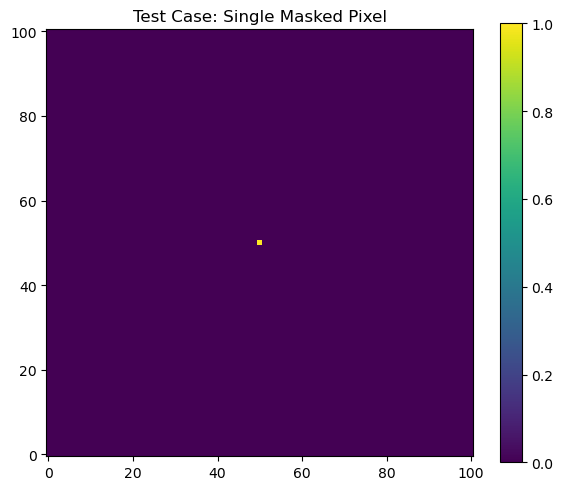

In [ ]:
# Create a test mfrac map with a single masked pixel
dim = 101
center = dim // 2

y_range = np.arange(dim)
x_range = np.arange(dim)

mfrac_single = np.zeros((dim, dim))
mfrac_single[center, center] = 1.0

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.imshow(mfrac_single, origin="lower", cmap="viridis")
ax.set_title("Test Case: Single Masked Pixel", fontsize=12)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Method 1: GalSim approach (current implementation)

In [ ]:
def compute_mfrac_galsim(mfrac, pixel_scale=0.2, fwhm=1.2):
    wcs = galsim.PixelScale(pixel_scale)

    _gsimage_orig = galsim.ImageD(mfrac, wcs=wcs)
    _gsimage_interp = galsim.InterpolatedImage(
        _gsimage_orig,
        normalization="sb",
    )
    _gsimage = galsim.Convolve(_gsimage_interp, galsim.Gaussian(fwhm=fwhm))
    _gsimage = _gsimage.drawImage(
        image=_gsimage_orig.copy(),
        method="sb",
    )
    _gsimage.wcs = None
    _gsimage.scale = 1.0
    _gsimage_final = galsim.InterpolatedImage(
        _gsimage,
        normalization="sb",
        offset=(_gsimage_interp.image.xmin, _gsimage_interp.image.ymin),
        use_true_center=False,
    )

    # Return both the interpolated object and the drawn array
    return _gsimage_final, _gsimage.array.copy()


# Test with single pixel
pixel_scale = 0.2
fwhm = 0.7

interp_galsim, drawn_galsim = compute_mfrac_galsim(mfrac_single, pixel_scale, fwhm)

print(f"  Original peak: {mfrac_single[center, center]:.6f}")
print(f"  Drawn peak: {drawn_galsim[center, center]:.6f}")

  Original peak: 1.000000
  Drawn peak: 0.071778


## Method 2: Direct convolution with Gaussian (pixel-based)

In [ ]:
from scipy.signal import convolve2d


def compute_mfrac_direct_convolve(mfrac, pixel_scale=0.2, fwhm=1.2, kernel_size=25):
    # Convert FWHM to sigma in pixel units
    fwhm_pixels = fwhm / pixel_scale
    sigma_pixels = fwhm_pixels / (2 * np.sqrt(2 * np.log(2)))

    # Create Gaussian kernel
    x = np.arange(-kernel_size // 2 + 1, kernel_size // 2 + 1)
    y = np.arange(-kernel_size // 2 + 1, kernel_size // 2 + 1)
    xx, yy = np.meshgrid(x, y)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma_pixels**2))
    kernel = kernel / np.sum(kernel)  # Normalize to conserve flux

    convolved = convolve2d(mfrac, kernel, mode="same", boundary="fill", fillvalue=0.0)

    return convolved, kernel


# Test with single pixel
convolved_direct, kernel = compute_mfrac_direct_convolve(
    mfrac_single, pixel_scale, fwhm
)

print(f"  Original peak: {mfrac_single[center, center]:.6f}")
print(f"  Convolved peak: {convolved_direct[center, center]:.6f}")

  Original peak: 1.000000
  Convolved peak: 0.072044


### Method 3: Real ngmix implementation

In [ ]:
def compute_mfrac_ngmix(mfrac, x_positions, y_positions, pixel_scale=0.2, fwhm=1.2):
    """
    This is to mimic Erin sheldon's metadetect repo
    """
    # Create Gaussian weight
    gauss_wgt = ngmix.GMixModel(
        [0, 0, 0, 0, ngmix.moments.fwhm_to_T(fwhm), 1],
        "gauss",
    )

    # Create weight map
    weight = np.ones_like(mfrac)

    # Measure mfrac at each position
    mfracs = []
    for x, y in zip(x_positions, y_positions):
        try:
            # Create a new jacobian for this position
            jacobian = ngmix.DiagonalJacobian(row=y, col=x, scale=pixel_scale)

            # Create a new observation for this position
            obs = ngmix.Observation(image=mfrac, weight=weight, jacobian=jacobian)

            stats = gauss_wgt.get_weighted_sums(obs, fwhm * 2)
            # Weighted average: sum of (weight * value) / sum of weights
            mfracs.append(stats["sums"][5] / stats["wsum"])
        except ngmix.GMixFatalError:
            mfracs.append(1.0)

    return np.array(mfracs)


# Test with single pixel - compute at all pixel positions
print("Computing ngmix mfrac (this may take a moment)...")
y_grid, x_grid = np.meshgrid(np.arange(dim), np.arange(dim), indexing="ij")
x_pos = x_grid.ravel()
y_pos = y_grid.ravel()

mfracs_ngmix = compute_mfrac_ngmix(
    mfrac_single, x_pos, y_pos, pixel_scale=pixel_scale, fwhm=fwhm
)
mfrac_ngmix = mfracs_ngmix.reshape(dim, dim)

print("\nReal ngmix implementation:")
print(f"  Original peak: {mfrac_single[center, center]:.6f}")
print(f"  ngmix peak: {mfrac_ngmix[center, center]:.6f}")
print(f"  Total flux (original): {np.sum(mfrac_single):.6f}")
print(f"  Total flux (ngmix): {np.sum(mfrac_ngmix):.6f}")

Computing ngmix mfrac (this may take a moment)...

Real ngmix implementation:
  Original peak: 1.000000
  ngmix peak: 0.072046
  Total flux (original): 1.000000
  Total flux (ngmix): 1.000000


## Visual Comparison

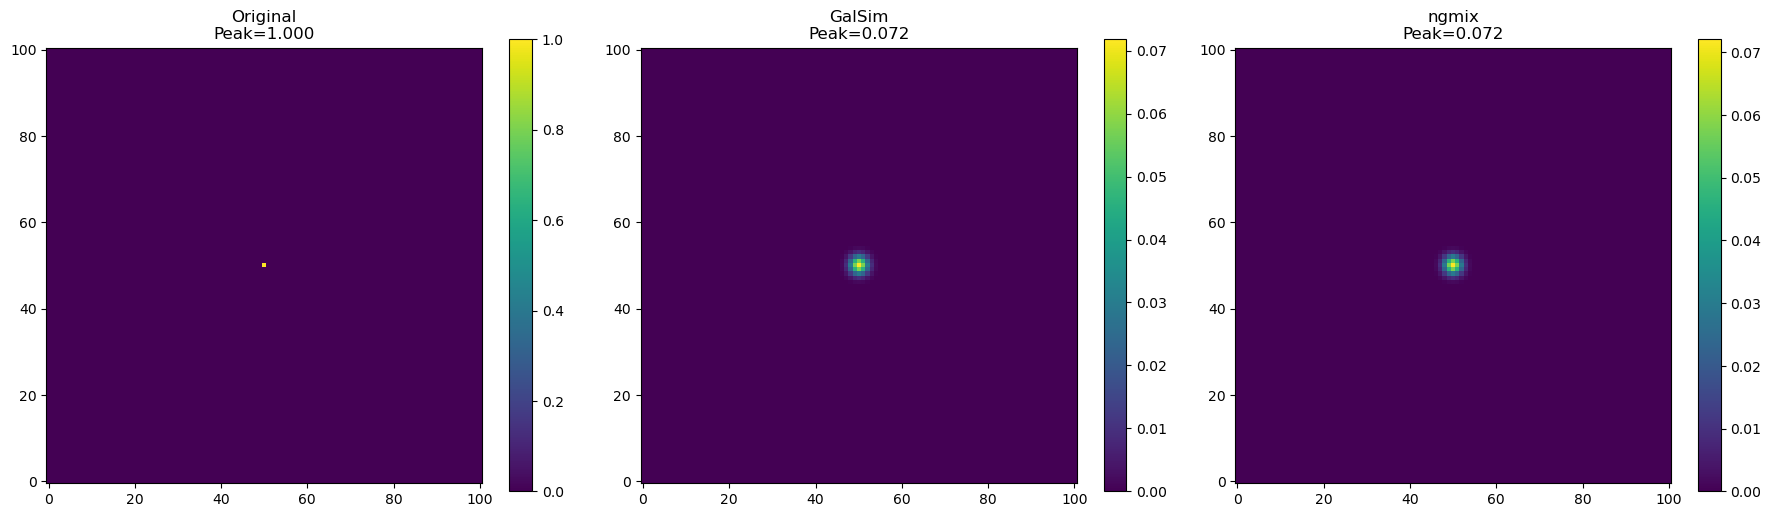

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
im0 = axes[0].imshow(mfrac_single, origin="lower", cmap="viridis")
axes[0].set_title(f"Original\nPeak={mfrac_single[center, center]:.3f}")
plt.colorbar(im0, ax=axes[0])

# GalSim
im1 = axes[1].imshow(drawn_galsim, origin="lower", cmap="viridis")
axes[1].set_title(f"GalSim\nPeak={drawn_galsim[center, center]:.3f}")
plt.colorbar(im1, ax=axes[1])

# ngmix
im2 = axes[2].imshow(mfrac_ngmix, origin="lower", cmap="viridis")
axes[2].set_title(f"ngmix\nPeak={mfrac_ngmix[center, center]:.3f}")
plt.colorbar(im2, ax=axes[2])


plt.tight_layout()
plt.show()

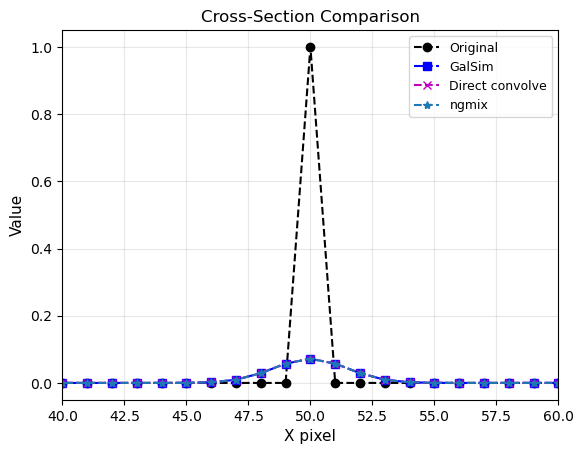

In [ ]:
# Cross sections
ax = plt.gca()
ax.plot(x_range, mfrac_single[center, :], "k--", label="Original", marker="o")
ax.plot(x_range, drawn_galsim[center, :], "b-.", label="GalSim", marker="s")
ax.plot(
    x_range, convolved_direct[center, :], "m--", label="Direct convolve", marker="x"
)
ax.plot(x_range, mfrac_ngmix[center, :], "--", label="ngmix", marker="*")
ax.set_xlim(center - 10, center + 10)
ax.set_xlabel("X pixel", fontsize=11)
ax.set_ylabel("Value", fontsize=11)
ax.set_title("Cross-Section Comparison", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

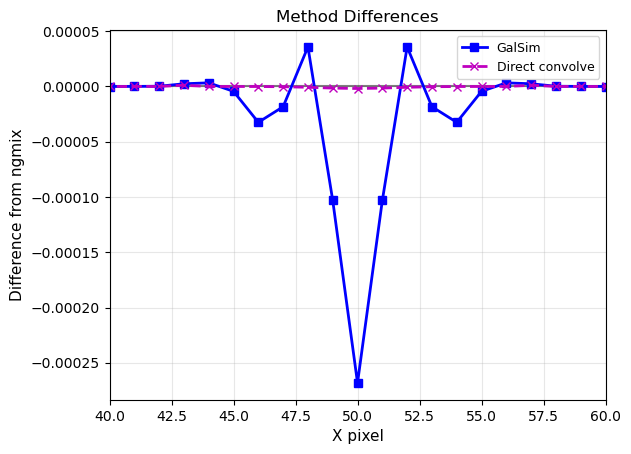

In [ ]:
# Differences from ngmix (reference)
diff_galsim = drawn_galsim - mfrac_ngmix
diff_direct = convolved_direct - mfrac_ngmix

ax = plt.gca()
ax.axhline(y=0, color="k", alpha=0.5)
ax.plot(x_range, diff_galsim[center, :], "b-", linewidth=2, label="GalSim", marker="s")
ax.plot(
    x_range,
    diff_direct[center, :],
    "m--",
    linewidth=2,
    label="Direct convolve",
    marker="x",
)

ax.set_xlim(center - 10, center + 10)
ax.set_xlabel("X pixel", fontsize=11)
ax.set_ylabel("Difference from ngmix", fontsize=11)
ax.set_title("Method Differences", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

## Test with different FWHM values

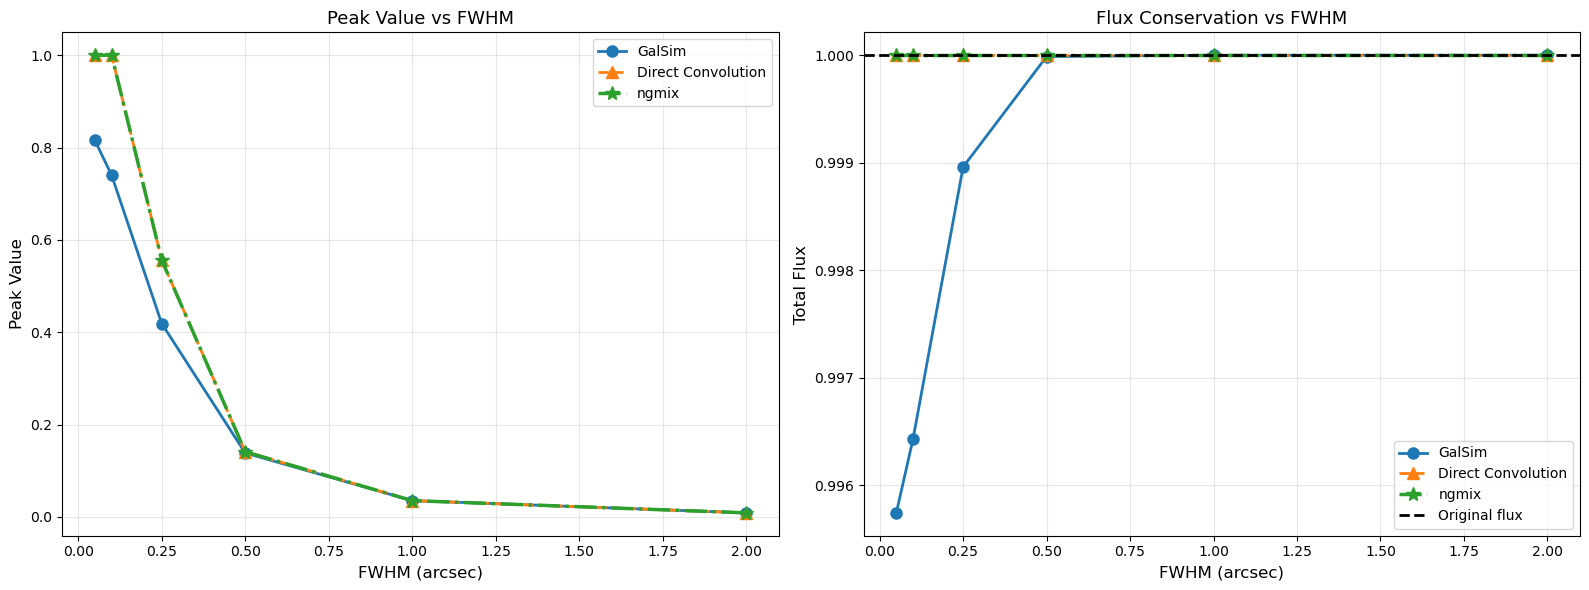

In [ ]:
# Test across different FWHM values
fwhm_test_values = [0.05, 0.1, 0.25, 0.5, 1.0, 2.0]

results_by_fwhm = []

for fwhm_test in fwhm_test_values:
    # GalSim
    interp_gs, drawn_gs = compute_mfrac_galsim(mfrac_single, pixel_scale, fwhm_test)

    # Direct
    convolved_d, _ = compute_mfrac_direct_convolve(mfrac_single, pixel_scale, fwhm_test)

    result = {
        "fwhm": fwhm_test,
        "galsim_peak": drawn_gs[center, center],
        "direct_peak": convolved_d[center, center],
        "galsim_flux": np.sum(drawn_gs),
        "direct_flux": np.sum(convolved_d),
    }

    y_grid, x_grid = np.meshgrid(np.arange(dim), np.arange(dim), indexing="ij")
    x_pos = x_grid.ravel()
    y_pos = y_grid.ravel()

    mfracs_ng = compute_mfrac_ngmix(
        mfrac_single, x_pos, y_pos, pixel_scale=pixel_scale, fwhm=fwhm_test
    )
    mfrac_ng = mfracs_ng.reshape(dim, dim)

    result["ngmix_peak"] = mfrac_ng[center, center]
    result["ngmix_flux"] = np.sum(mfrac_ng)

    results_by_fwhm.append(result)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fwhm_arr = [r["fwhm"] for r in results_by_fwhm]

# Peak values
axes[0].plot(
    fwhm_arr,
    [r["galsim_peak"] for r in results_by_fwhm],
    "o-",
    linewidth=2,
    markersize=8,
    label="GalSim",
)
axes[0].plot(
    fwhm_arr,
    [r["direct_peak"] for r in results_by_fwhm],
    "^--",
    linewidth=2,
    markersize=8,
    label="Direct Convolution",
)

axes[0].plot(
    fwhm_arr,
    [r["ngmix_peak"] for r in results_by_fwhm],
    "*-.",
    linewidth=2.5,
    markersize=10,
    label="ngmix",
)
axes[0].set_xlabel("FWHM (arcsec)", fontsize=12)
axes[0].set_ylabel("Peak Value", fontsize=12)
axes[0].set_title("Peak Value vs FWHM", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Total flux
axes[1].plot(
    fwhm_arr,
    [r["galsim_flux"] for r in results_by_fwhm],
    "o-",
    linewidth=2,
    markersize=8,
    label="GalSim",
)
axes[1].plot(
    fwhm_arr,
    [r["direct_flux"] for r in results_by_fwhm],
    "^--",
    linewidth=2,
    markersize=8,
    label="Direct Convolution",
)

axes[1].plot(
    fwhm_arr,
    [r["ngmix_flux"] for r in results_by_fwhm],
    "*-.",
    linewidth=2.5,
    markersize=10,
    label="ngmix",
)
axes[1].axhline(y=1.0, color="k", linestyle="--", linewidth=2, label="Original flux")
axes[1].set_xlabel("FWHM (arcsec)", fontsize=12)
axes[1].set_ylabel("Total Flux", fontsize=12)
axes[1].set_title("Flux Conservation vs FWHM", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Check total flux

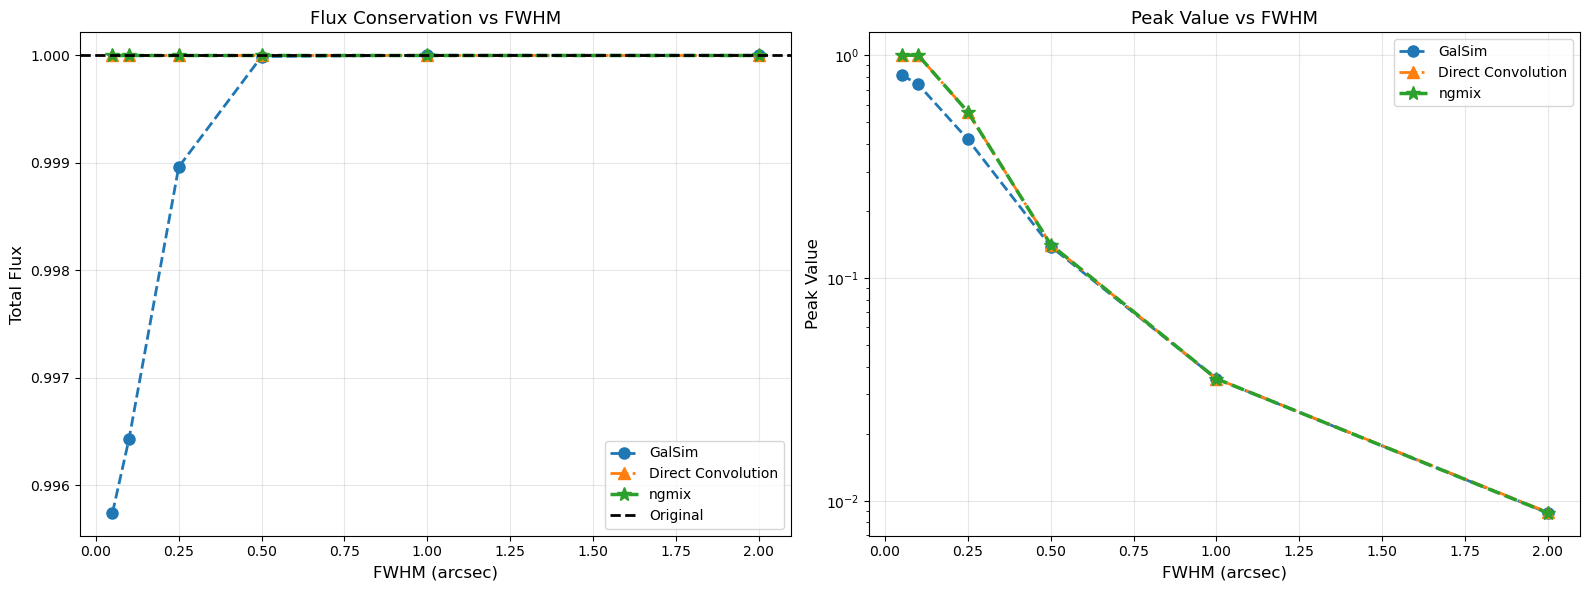

In [ ]:
# Test normalization with different FWHM values
fwhm_test_values = [0.05, 0.1, 0.25, 0.5, 1.0, 2.0]
pixel_scale_fixed = 0.2

normalization_results = []

for fwhm_val in fwhm_test_values:
    # GalSim
    interp_gs, drawn_gs = compute_mfrac_galsim(
        mfrac_single, pixel_scale_fixed, fwhm_val
    )

    # Direct
    convolved_d, _ = compute_mfrac_direct_convolve(
        mfrac_single, pixel_scale_fixed, fwhm_val
    )

    result = {
        "fwhm": fwhm_val,
        "galsim_flux": np.sum(drawn_gs),
        "direct_flux": np.sum(convolved_d),
        "galsim_peak": drawn_gs[center, center],
        "direct_peak": convolved_d[center, center],
    }

    # ngmix (if available)
    y_grid, x_grid = np.meshgrid(np.arange(dim), np.arange(dim), indexing="ij")
    x_pos = x_grid.ravel()
    y_pos = y_grid.ravel()

    mfracs_ng = compute_mfrac_ngmix(
        mfrac_single, x_pos, y_pos, pixel_scale=pixel_scale_fixed, fwhm=fwhm_val
    )
    mfrac_ng = mfracs_ng.reshape(dim, dim)

    result["ngmix_peak"] = mfrac_ng[center, center]
    result["ngmix_flux"] = np.sum(mfrac_ng)

    normalization_results.append(result)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fwhm_arr = [r["fwhm"] for r in normalization_results]

# Flux conservation
axes[0].plot(
    fwhm_arr,
    [r["galsim_flux"] for r in normalization_results],
    "o--",
    linewidth=2,
    markersize=8,
    label="GalSim",
)
axes[0].plot(
    fwhm_arr,
    [r["direct_flux"] for r in normalization_results],
    "^-.",
    linewidth=2,
    markersize=8,
    label="Direct Convolution",
)
axes[0].plot(
    fwhm_arr,
    [r["ngmix_flux"] for r in normalization_results],
    "*--",
    linewidth=2.5,
    markersize=10,
    label="ngmix",
)
axes[0].axhline(y=1.0, color="k", linestyle="--", linewidth=2, label="Original")
axes[0].set_xlabel("FWHM (arcsec)", fontsize=12)
axes[0].set_ylabel("Total Flux", fontsize=12)
axes[0].set_title("Flux Conservation vs FWHM", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Peak values
axes[1].semilogy(
    fwhm_arr,
    [r["galsim_peak"] for r in normalization_results],
    "o--",
    linewidth=2,
    markersize=8,
    label="GalSim",
)
axes[1].semilogy(
    fwhm_arr,
    [r["direct_peak"] for r in normalization_results],
    "^-.",
    linewidth=2,
    markersize=8,
    label="Direct Convolution",
)
axes[1].semilogy(
    fwhm_arr,
    [r["ngmix_peak"] for r in normalization_results],
    "*--",
    linewidth=2.5,
    markersize=10,
    label="ngmix",
)
axes[1].set_xlabel("FWHM (arcsec)", fontsize=12)
axes[1].set_ylabel("Peak Value", fontsize=12)
axes[1].set_title("Peak Value vs FWHM", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()